In [8]:
# ==========================================
# STEP 1 - IMPORT REQUIRED LIBRARIES
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# TensorFlow and Keras libraries

# MNIST contains 70,000 grayscale images of handwritten digits (0–9). Each image is 28 × 28 pixels.
from tensorflow.keras.datasets import mnist   # It automatically splits the data into: 60,000 training images 10,000 testing images
from tensorflow.keras.models import Sequential # Creates a neural network by stacking layers one after another.
from tensorflow.keras.layers import Conv2D # Detects edges. Detects curves. Detects textures. Learns image features automatically
from tensorflow.keras.layers import MaxPooling2D # Reduces the size of feature maps. Reduces computation. Reduces memory usage. Helps prevent overfitting. Keeps the most important features
from tensorflow.keras.layers import Flatten # Converts a 2D (or 3D) feature map into a 1D vector.
from tensorflow.keras.layers import Dense, Input # Adds a fully connected (neural) layer.
from tensorflow.keras.utils import to_categorical # Converts class labels into one-hot encoded vectors.

In [9]:
# ==========================================
# STEP 2 - LOAD MNIST DATASET
# ==========================================

# Load dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)


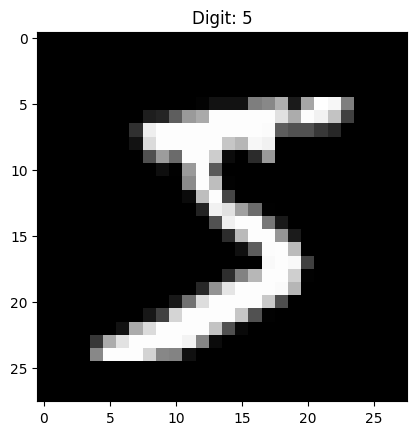

5


In [10]:
# ==========================================
# STEP 3 - DISPLAY SAMPLE IMAGE
# ==========================================
# It: displays the first handwritten image. shows its actual digit label. prints the label separately
# x_train contains images and y_train contains the correct lables

plt.imshow(X_train[0], cmap='gray') # first image in training dataset X_train contains the image and each is 28*28 pixel matrix
# imshow is used to display image and in gray scale
plt.title('Digit: {}'.format(y_train[0]))
plt.show()
print(y_train[0])

In [11]:
# ==========================================
# STEP 4 - RESHAPE DATA
# ==========================================

# CNN expects 4D input:
# (samples, height, width, channels)  CNN input format: (batch_size, height, width, channels)
#channels tell us colour info ex grey scale means  channel=1 , RGB means channel=3
#here this dataset has all grey scale so channel =1

X_train = X_train.reshape((60000, 28, 28, 1))
X_test = X_test.reshape((10000, 28, 28, 1))
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [12]:
# ==========================================
# STEP 5 - NORMALIZE PIXEL VALUES
# ==========================================

# Convert pixel values from:  This is like feature scaling
# 0-255  →  0-1
# Images are internally just pixel numbers from 0–255, and feature scaling converts them into smaller values (0–1) so CNN can learn more efficiently.

X_train = X_train / 255.0
X_test = X_test / 255.0

In [13]:
# ==========================================
# STEP 6 - ENCODE TARGET VALUES
# ==========================================

# Convert labels into categorical format
# Example:
# 5 → [0 0 0 0 0 1 0 0 0 0]

# One-Hot Encoding

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [15]:
# ==========================================
# STEP 7 - BUILD CNN MODEL
# ==========================================

model = Sequential()

# ------------------------------------------
# FIRST CNN LAYER
# ------------------------------------------

# Input layer   --- we are telling the model what kind of data is coming in as input

model.add(
    Input(
        shape=(28,28,1)
    )
)   ## cnn learns image by its dimensions 28*28 and its grey scale

# CNN layer   -this is main work where  CNN scans image and tries to detect:
# edges  curves  shapes  patterns  like human vision
##  kernel_size=(3,3  tells us the area size it can see at once. smaller size means it covers small area . it can also see 5,5 -large area
## but that would increase computation and slows down process
## filters means no of visual patterns it can learn liked edges, circle, curves, corners etc

model.add(
    Conv2D(
        filters = 32,
        kernel_size = (3,3),
        activation = 'relu'
    )
)

# ------------------------------------------
# MAX POOLING LAYER
# ------------------------------------------
  ## to reduce the size generated by prev layer which may be too big for learning and processing

model.add(
    MaxPooling2D(
        pool_size = (2,2)
    )
)

# ------------------------------------------
# FLATTEN LAYER
# ------------------------------------------
# convet the multi dimensional image like data to a single dimention layer because denser layer (hidden ) would need 1d vector data
model.add(Flatten())

# ------------------------------------------
# HIDDEN DENSE LAYER
# ------------------------------------------
 # This Dense layer acts like an ANN hidden layer that learns combinations of image features to help identify the correct digit.
 #Why 128? again No fixed rule.
# Common   values: 64 /128 /256
# More neurons: more learning capacity ,but slower training,more overfitting risk
#128 is a very common balanced choice.
# relu again activation help learn better patterns

model.add(
    Dense(
        units = 128,
        activation = 'relu'
    )
)

# ------------------------------------------
# OUTPUT LAYER
# ------------------------------------------

# 10 neurons because digits are: from  0 to 9
# softmax convert output into probablities
# the output layer uses 10 neurons and softmax activation to predict probabilities for digits 0–9 and choose the most likely digit.

model.add(
    Dense(
        units=10,
        activation='softmax'
    )
)

In [17]:
# ==========================================
# STEP 8 - COMPILE MODEL
# ==========================================
# compiler “Configure the learning process”  compile() configures how the CNN learns, measures errors, and tracks prediction accuracy during training.
# Optimizer controls: HOW weights change

model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy', # checks for loss wrong predictionns
    metrics = ['accuracy']
)

In [18]:
# ==========================================
# STEP 9 - TRAIN MODEL
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,   # process 32 images per one time
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9505 - loss: 0.1654 - val_accuracy: 0.9771 - val_loss: 0.0804
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9818 - loss: 0.0572 - val_accuracy: 0.9823 - val_loss: 0.0580
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9883 - loss: 0.0368 - val_accuracy: 0.9833 - val_loss: 0.0585
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9921 - loss: 0.0239 - val_accuracy: 0.9852 - val_loss: 0.0529
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9945 - loss: 0.0173 - val_accuracy: 0.9845 - val_loss: 0.0536


In [19]:
# ==========================================
# STEP 10 - EVALUATE MODEL
# ==========================================

loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)
print(history.history['accuracy'])
print(history.history['val_accuracy'])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9856 - loss: 0.0468

Test Accuracy: 0.9855999946594238
[0.9505000114440918, 0.9817916750907898, 0.9882708191871643, 0.9920833110809326, 0.9944999814033508]
[0.9770833253860474, 0.9823333621025085, 0.9833333492279053, 0.9851666688919067, 0.984499990940094]


In [20]:
# ==========================================
# STEP 11 - MAKE PREDICTIONS
#argmax means  - arg-index  , max=largest value
# predictions[0] would give this type of result [0.01, 0.02, 0.90, 0.01, 0.00, 0.03, 0.01, 0.01, 0.00, 0.01]
#What Does This Mean?
#Index	Digit	Probability
#0	digit 0	1%
#1	digit 1	2%
#2	digit 2	90% - high probability
#3	digit 3	1%   and so on

# so now CNN can  tell  “this image is digit 2 with highest confidence.”
# this is how prediction is done and argmax is used for this
# ==========================================

predictions = model.predict(X_test)

# Get predicted class
predicted_digit = np.argmax(predictions[0])

print("\nPredicted Digit:", predicted_digit)
print("Actual:", np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Predicted Digit: 7
Actual: 7


In [21]:
### in case we want to predict the train data itself - what we iniially send as input, plz run this code

predictions = model.predict(X_train)

# Get predicted class
predicted_digit = np.argmax(predictions[0])

print("\nPredicted Digit:", predicted_digit)
print("Actual:", np.argmax(y_train[0]))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step

Predicted Digit: 5
Actual: 5


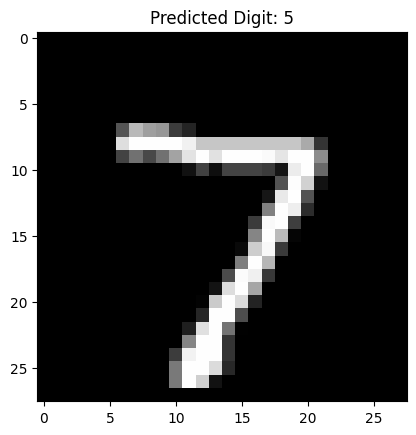

In [23]:
from numpy._core.fromnumeric import reshape
# ==========================================
# STEP 12 - DISPLAY TEST IMAGE
# ==========================================

plt.imshow(X_test[0].reshape(28,28), cmap = 'gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.show()